# Cross-run feature stability analysis

We have five independent runs (**A**, **B**, **D**, **E**, **F**) on `clemsonc6420`, each
collecting 20 neutral + 20 emotional trials. Hardware counters are noisy — thermal drift,
LLC residency, scheduling jitter — so any single run can produce features that look
discriminative by chance.

This notebook asks: **which features are reliably informative across the majority of runs?**

We check four things per feature:

| Check | Meaning | Threshold |
|---|---|---|
| **Rank consistency** | Does it stay near the top? | Mean rank ≤ 50, low std |
| **Sign consistency** | Same direction every time? | ≥ 60% of runs agree |
| **Significance** | Clears p < 0.05 how often? | ≥ 60% of runs |
| **ARI consistency** | Clusters well and stably? | Mean > 0.05, low std |


In [142]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (14, 6)

BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'
FEAT_DIR = BASE_DIR / 'data' / 'featrank'
RESULTS_DIR = BASE_DIR / 'results' / 'cross_run_stability'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUNS = ['A', 'B', 'D','E','F']
N_RUNS = len(RUNS)

print(f'BASE_DIR  = {BASE_DIR}')
print(f'FEAT_DIR  = {FEAT_DIR}')
print(f'RESULTS   = {RESULTS_DIR}')
print(f'Runs: {RUNS}')

BASE_DIR  = /Users/rsalvi/Desktop/mccviahat
FEAT_DIR  = /Users/rsalvi/Desktop/mccviahat/data/featrank
RESULTS   = /Users/rsalvi/Desktop/mccviahat/results/cross_run_stability
Runs: ['A', 'B', 'D', 'E', 'F']


## 2 — Load per-run CSVs

Each run has:
- `pval<R>.csv` — Mann-Whitney U (p-value, effect size, direction)
- `ARI<R>.csv`  — KMeans k=2 clustering scores (ARI, accuracy)
- `Att<R>.csv`  — Confounder attenuation (partial r after removing elapsed_ms)

We merge pval + ARI per run, compute a composite rank (average of p-rank and ARI-rank),
then stack into one long-form table.


In [143]:
frames = []
for run in RUNS:
    pval = pd.read_csv(FEAT_DIR / f'pval{run}.csv', index_col=0)
    ari  = pd.read_csv(FEAT_DIR / f'ARI{run}.csv',  index_col=0)

    merged = pval.merge(ari[['feature', 'ari', 'acc', 'sc_ari', 'sc_acc']],
                        on='feature', how='outer')
    merged['run'] = run

    # Composite rank: average of p-rank and ARI-rank (lower = better)
    merged['p_rank']   = merged['p'].rank()
    merged['ari_rank'] = (-merged['ari']).rank()
    merged['composite_rank'] = merged[['p_rank', 'ari_rank']].mean(axis=1)

    frames.append(merged)

df = pd.concat(frames, ignore_index=True)

# Parse indicator and metric from feature name
df['indicator'] = df['feature'].str.rsplit('__', n=1).str[0]
df['metric']    = df['feature'].str.rsplit('__', n=1).str[1]

print(f'Loaded {len(df)} rows  ({len(df.feature.unique())} unique features × {N_RUNS} runs)')
print(f'Columns: {list(df.columns)}')
print()
for run in RUNS:
    sub = df[df.run == run]
    print(f'  Run {run}: {len(sub)} features')

Loaded 1473 rows  (300 unique features × 5 runs)
Columns: ['feature', 'U', 'p', 'effect_r', 'n_mean', 'e_mean', 'direction', 'ari', 'acc', 'sc_ari', 'sc_acc', 'run', 'p_rank', 'ari_rank', 'composite_rank', 'indicator', 'metric']

  Run A: 300 features
  Run B: 298 features
  Run D: 293 features
  Run E: 291 features
  Run F: 291 features


## 3 — Aggregate across runs

For each feature we compute:
- **rank_mean / rank_std** — where it sits on average and how much it moves
- **ari_mean / ari_std** — clustering quality and its session-to-session variance
- **p_sig_pct** — fraction of the runs it appears in where p < 0.05
- **sign_agree_pct** — fraction of runs where the direction (↑E or ↓E) matches the majority

All percentages are relative to `n_runs` (the number of runs each feature appears in),
so a feature present in only 2/3 runs is judged fairly against those 2 runs.


In [144]:
def _sign_summary(group):
    """Return the majority direction and how many runs agree."""
    dirs = group.dropna()
    if dirs.empty:
        return pd.Series({'sign_mode': None, 'sign_agree': 0})
    mode = dirs.mode().iloc[0]
    return pd.Series({'sign_mode': mode, 'sign_agree': (dirs == mode).sum()})


agg = df.groupby('feature').agg(
    rank_mean       = ('composite_rank', 'mean'),
    rank_std        = ('composite_rank', 'std'),
    rank_min        = ('composite_rank', 'min'),
    rank_max        = ('composite_rank', 'max'),
    ari_mean        = ('ari', 'mean'),
    ari_std         = ('ari', 'std'),
    ari_max         = ('ari', 'max'),
    acc_mean        = ('acc', 'mean'),
    sc_ari_mean     = ('sc_ari', 'mean'),
    p_mean          = ('p', 'mean'),
    p_median        = ('p', 'median'),
    effect_r_mean   = ('effect_r', 'mean'),
    n_runs          = ('run', 'count'),
).reset_index()

# p < 0.05 count per feature
p_sig = df.groupby('feature')['p'].apply(lambda x: (x < 0.05).sum()).reset_index(name='p_sig_count')
agg = agg.merge(p_sig, on='feature')

# Sign consistency
sign_agg = df.groupby('feature')['direction'].apply(
    lambda g: _sign_summary(g)
).reset_index()
# Flatten if needed
if isinstance(sign_agg.columns, pd.MultiIndex):
    sign_agg.columns = ['feature', 'sign_mode', 'sign_agree']
elif 'sign_mode' not in sign_agg.columns:
    sign_df = df.groupby('feature')['direction'].apply(_sign_summary).unstack().reset_index()
    sign_df.columns = ['feature', 'sign_mode', 'sign_agree']
    sign_agg = sign_df

agg = agg.merge(sign_agg, on='feature')
agg['sign_agree'] = agg['sign_agree'].astype(int)

# ── Convert counts to percentages of the runs each feature appears in ─
# This avoids misleading "3/4" for a feature that only appeared in 3 runs
# (that's 100%, not 75%).
agg['p_sig_pct']    = agg['p_sig_count'] / agg['n_runs']     # 0.0–1.0
agg['sign_agree_pct'] = agg['sign_agree'] / agg['n_runs']    # 0.0–1.0

# Parse indicator / metric
agg['indicator'] = agg['feature'].str.rsplit('__', n=1).str[0]
agg['metric']    = agg['feature'].str.rsplit('__', n=1).str[1]

# Sort by rank_mean
agg = agg.sort_values('rank_mean').reset_index(drop=True)

print(f'Summary table: {len(agg)} features')
print(f'Features present in all {N_RUNS} runs: {(agg.n_runs == N_RUNS).sum()}')
print(f'Features missing from ≥1 run: {(agg.n_runs < N_RUNS).sum()}')
print()
print('=== Top 30 by mean composite rank ===')
show_cols = ['feature', 'rank_mean', 'rank_std', 'ari_mean', 'ari_std',
             'p_sig_pct', 'sign_mode', 'sign_agree_pct', 'n_runs']
print(agg.head(30)[show_cols].to_string(index=False, float_format='{:.2f}'.format))


Summary table: 300 features
Features present in all 5 runs: 291
Features missing from ≥1 run: 9

=== Top 30 by mean composite rank ===
                                  feature  rank_mean  rank_std  ari_mean  ari_std  p_sig_pct sign_mode  sign_agree_pct  n_runs
msr/cpu_thermal_margin/__spectral_entropy      72.25     35.48      0.02     0.02       0.20        ↓E            1.00       5
              cache-misses__lz_complexity      73.75     76.04      0.05     0.06       0.40        ↑E            0.80       5
          irq:irq_handler_exit__mean_rate      76.55     67.59      0.07     0.08       0.40        ↓E            0.80       5
         irq:irq_handler_entry__mean_rate      76.55     67.59      0.07     0.08       0.40        ↓E            0.80       5
                irq:softirq_exit__p90_p10      78.35     75.52      0.04     0.05       0.20        ↑E            0.80       5
      irq:irq_handler_exit__lz_complexity      83.50     87.65      0.03     0.04       0.20        ↓E 

## 4 — Plot 1: Rank consistency

Bar = mean composite rank across 5 runs; error bar = ±1 std.
Short bars on the left with tiny error bars = best candidates.
Colour = sign consistency (green = 100%, yellow = ≥80%, orange = ≥60%, red = <60%).


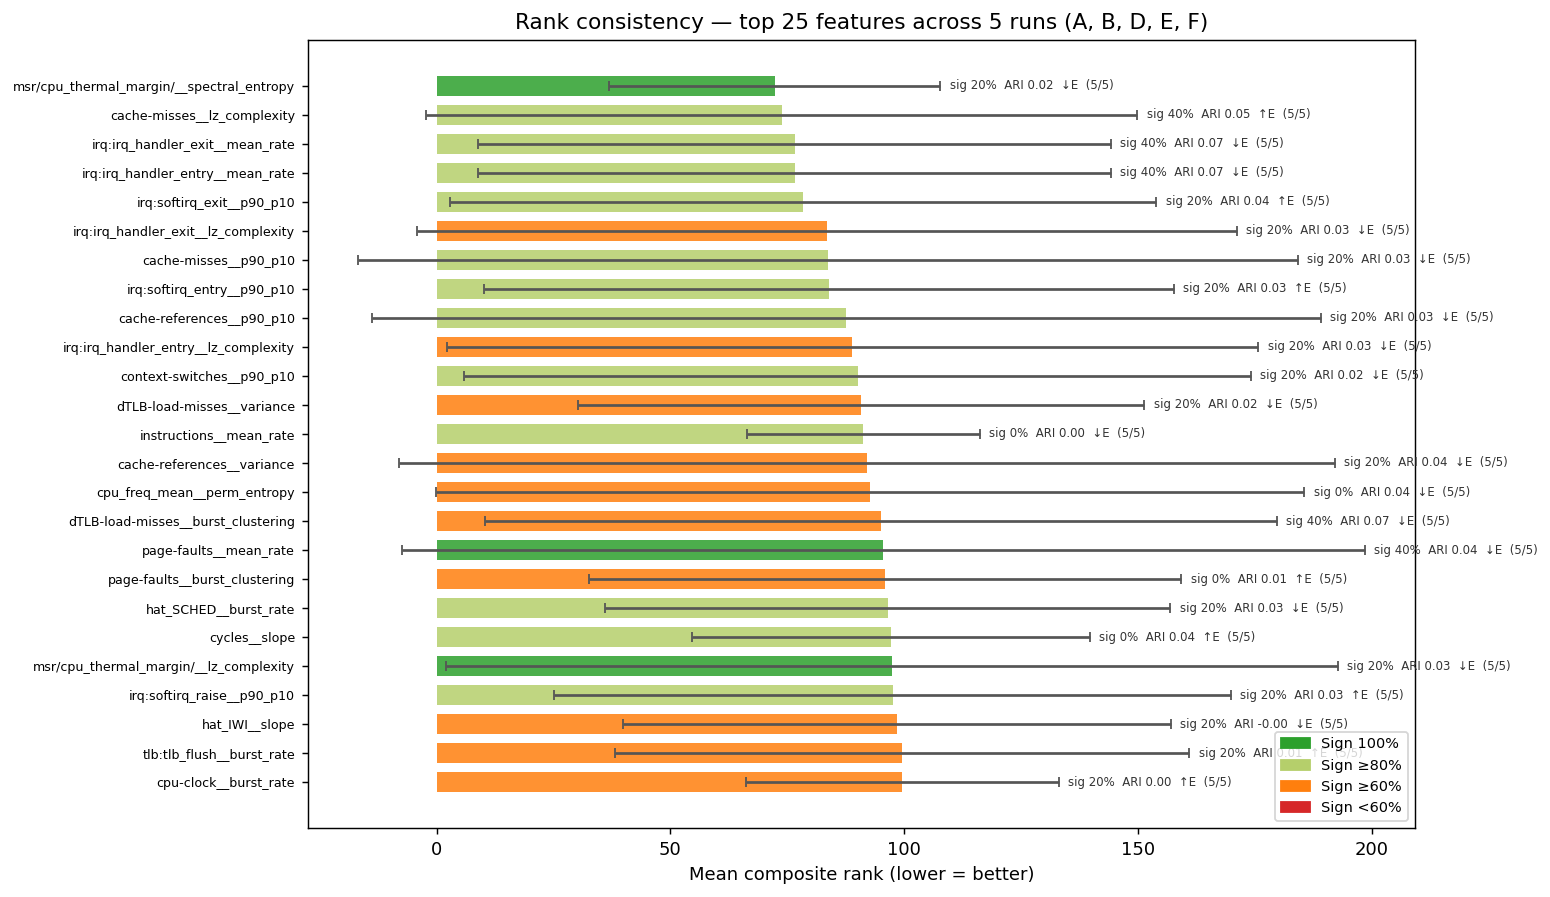

In [145]:
TOP_N = 25
top = agg.head(TOP_N).copy()

# Colour by sign consistency — 4 tiers for 5 runs
def _sign_color(pct):
    if pct >= 1.0:   return '#2ca02c'   # green  — 5/5
    if pct >= 0.80:  return '#b5cf6b'   # yellow-green — 4/5
    if pct >= 0.60:  return '#ff7f0e'   # orange — 3/5
    return '#d62728'                     # red    — <3/5

bar_colors = [_sign_color(p) for p in top['sign_agree_pct']]

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(TOP_N)

ax.barh(y_pos, top['rank_mean'], xerr=top['rank_std'].fillna(0),
        color=bar_colors, alpha=0.85, capsize=3, ecolor='#555', height=0.7)

# Annotation: sig%, ARI, direction, n_runs
for i, (_, r) in enumerate(top.iterrows()):
    ax.text(r['rank_mean'] + (r['rank_std'] if pd.notna(r['rank_std']) else 0) + 2,
            i, f"sig {r['p_sig_pct']:.0%}  ARI {r['ari_mean']:.2f}  {r['sign_mode'] or '?'}  ({r['n_runs']:.0f}/{N_RUNS})",
            va='center', fontsize=6.5, color='#333')

ax.set_yticks(y_pos)
ax.set_yticklabels(top['feature'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Mean composite rank (lower = better)')
ax.set_title(f'Rank consistency — top {TOP_N} features across {N_RUNS} runs ({", ".join(RUNS)})')

ax.legend(handles=[
    Patch(color='#2ca02c', label='Sign 100%'),
    Patch(color='#b5cf6b', label='Sign ≥80%'),
    Patch(color='#ff7f0e', label='Sign ≥60%'),
    Patch(color='#d62728', label='Sign <60%'),
], loc='lower right', fontsize=8)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'rank_consistency.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 — Plot 2: ARI consistency (mean vs std)

Each dot is a feature. x = mean KMeans ARI, y = std across runs.
**Bottom-right = best** (high ARI, low variance — stable and discriminative).
Top-right = volatile (may be exploiting session-specific artefacts).
Colour = fraction of runs where p < 0.05.


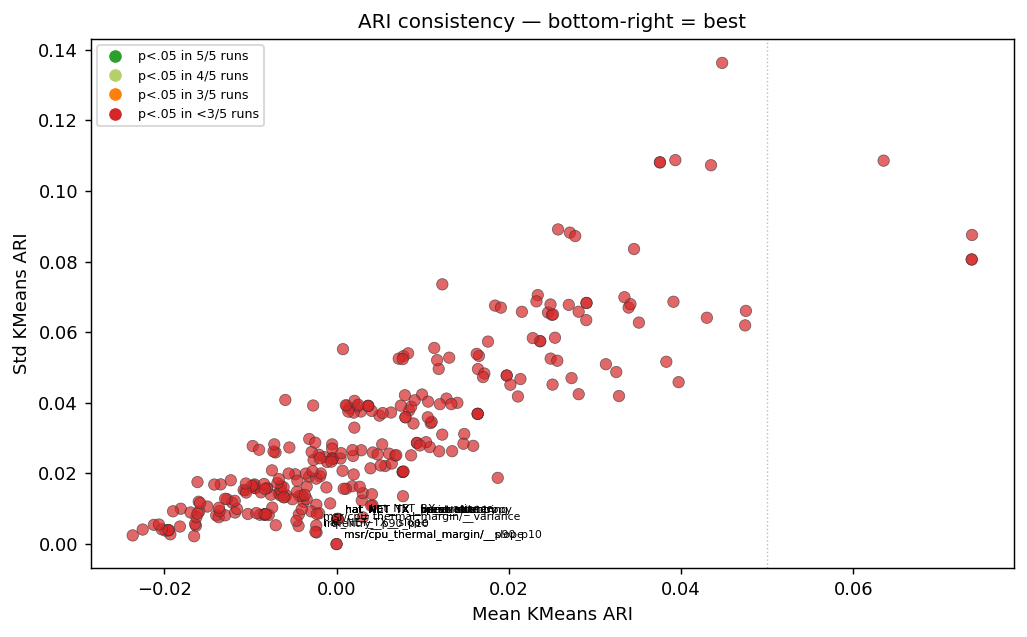

Saved → /Users/rsalvi/Desktop/mccviahat/results/cross_run_stability/ari_consistency.png


In [146]:
full = agg.copy()

fig, ax = plt.subplots(figsize=(8, 5))

# Colour by p_sig_pct — 4 tiers for 5 runs
colors = []
for pct in full['p_sig_pct']:
    if pct >= 1.0:
        colors.append('#2ca02c')   # green — 5/5
    elif pct >= 0.80:
        colors.append('#b5cf6b')   # yellow-green — 4/5
    elif pct >= 0.60:
        colors.append('#ff7f0e')   # orange — 3/5
    else:
        colors.append('#d62728')   # red — <3/5

ax.scatter(full['ari_mean'], full['ari_std'], c=colors,
           s=40, alpha=0.7, edgecolors='#333', linewidths=0.4)

# Label top-12 most stable features (high mean ARI, low std)
full['_score'] = full['ari_mean'] - 2 * full['ari_std'].fillna(0)
label_set = full.nlargest(12, '_score')
for _, row in label_set.iterrows():
    short = row['feature'].replace('irq:irq_handler_', 'irq:')
    ax.annotate(short, (row['ari_mean'], row['ari_std']),
                fontsize=6, ha='left', va='bottom',
                xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean KMeans ARI', fontsize=10)
ax.set_ylabel('Std KMeans ARI', fontsize=10)
ax.set_title('ARI consistency — bottom-right = best', fontsize=11)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c',
           markersize=8, label=f'p<.05 in 5/5 runs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#b5cf6b',
           markersize=8, label=f'p<.05 in 4/5 runs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e',
           markersize=8, label=f'p<.05 in 3/5 runs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=8, label=f'p<.05 in <3/5 runs'),
]
ax.legend(handles=handles, fontsize=7, loc='upper left')

ax.axvline(0.05, color='gray', ls=':', lw=0.8, alpha=0.5)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'ari_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/ari_consistency.png')


## 6 — Plot 3: Rank trajectories (top features)

How each top feature's composite rank moves across the 5 runs.
Flat lines = stable ranking; crossing lines = unstable.


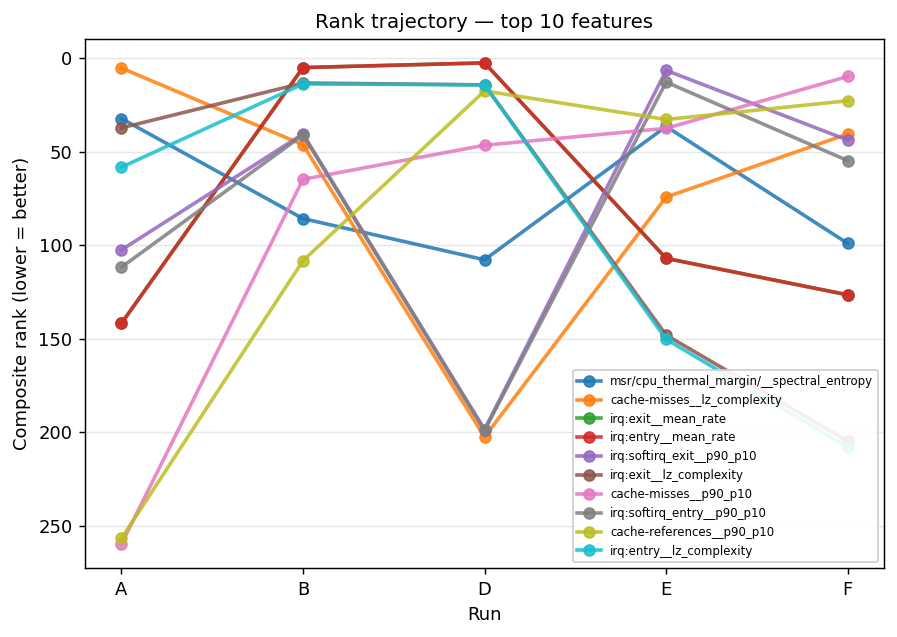

In [147]:
TOP_BUMP = 10
bump_feats = agg.head(TOP_BUMP)['feature'].tolist()
bump_df = df[df['feature'].isin(bump_feats)].copy()

fig, ax = plt.subplots(figsize=(7, 5))

cmap_bump = cm.get_cmap('tab10', TOP_BUMP)
for i, feat in enumerate(bump_feats):
    sub = bump_df[bump_df.feature == feat].sort_values('run')
    short = feat.replace('irq:irq_handler_', 'irq:')
    ax.plot(sub['run'], sub['composite_rank'], marker='o', lw=2,
            color=cmap_bump(i), alpha=0.85, label=short, markersize=6)

ax.set_xlabel('Run', fontsize=10)
ax.set_ylabel('Composite rank (lower = better)', fontsize=10)
ax.set_title(f'Rank trajectory — top {TOP_BUMP} features', fontsize=11)
ax.invert_yaxis()
ax.legend(fontsize=6.5, loc='lower right', ncol=1, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'rank_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 — Plot 4: Significance heatmap

Features × runs grid (5 columns). Colour = −log₁₀(p), with direction arrows and ★ for p < 0.05.
Quickly spots features that are significant in every run vs only some.


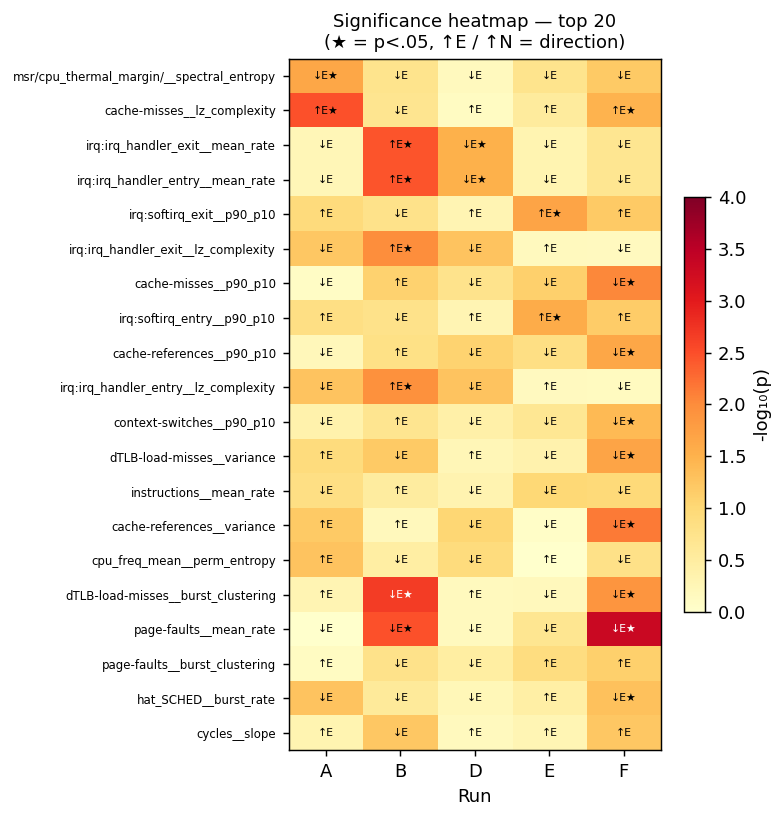

In [148]:
TOP_HEAT = 20
heat_feats = agg.head(TOP_HEAT)['feature'].tolist()
heat_df = df[df['feature'].isin(heat_feats)].copy()

# Pivot: features × runs
pivot_p = heat_df.pivot_table(index='feature', columns='run',
                               values='p', aggfunc='first')
pivot_dir = heat_df.pivot_table(index='feature', columns='run',
                                 values='direction', aggfunc='first')

row_order = [f for f in heat_feats if f in pivot_p.index]
pivot_p   = pivot_p.reindex(row_order).reindex(columns=RUNS)
pivot_dir = pivot_dir.reindex(row_order).reindex(columns=RUNS)
neglog = -np.log10(pivot_p.values.astype(float) + 1e-15)

fig, ax = plt.subplots(figsize=(max(5, N_RUNS * 1.2), max(5, TOP_HEAT * 0.32)))
im = ax.imshow(neglog, cmap='YlOrRd', aspect='auto', vmin=0,
               vmax=max(4, np.nanmax(neglog)))
plt.colorbar(im, ax=ax, shrink=0.6, label='-log₁₀(p)')

# Annotate each cell
for i in range(len(row_order)):
    for j, run in enumerate(RUNS):
        p_val = pivot_p.values[i, j]
        d_val = pivot_dir.values[i, j]
        if pd.notna(p_val):
            sig = '★' if p_val < 0.05 else ''
            txt = f'{d_val}{sig}' if pd.notna(d_val) else f'{p_val:.2f}'
            fg = 'white' if neglog[i, j] > 2.5 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=6, color=fg)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=6, color='gray')

ax.set_xticks(range(len(RUNS)))
ax.set_xticklabels(RUNS, fontsize=10)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(row_order, fontsize=6.5)
ax.set_xlabel('Run')
ax.set_title(f'Significance heatmap — top {TOP_HEAT}\n(★ = p<.05, ↑E / ↑N = direction)',
             fontsize=10)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 — Robust feature shortlist

Five gates — a feature must pass **all** to be recommended:

1. Present in **≥3 / 5** runs (60%)
2. Mean composite rank in top 50
3. Direction sign agrees in **≥60%** of its runs
4. Significant (p < 0.05) in **≥40%** of its runs
5. Mean ARI > 0.05

With 5 runs, 60% = 3/5 is a reasonable majority threshold.


In [149]:
RANK_CUTOFF  = 50
MIN_RUNS     = 3        # present in ≥3/5 runs (60%)
SIGN_PCT_MIN = 0.60     # direction agrees in ≥60% of runs
PSIG_PCT_MIN = 0.40     # p<0.05 in ≥40% of runs
ARI_MIN      = 0.05

robust = agg[
    (agg.n_runs >= MIN_RUNS) &
    (agg.rank_mean <= RANK_CUTOFF) &
    (agg.sign_agree_pct >= SIGN_PCT_MIN) &
    (agg.p_sig_pct >= PSIG_PCT_MIN) &
    (agg.ari_mean > ARI_MIN)
].copy()

robust = robust.sort_values('rank_mean').reset_index(drop=True)

print(f'=== ROBUST FEATURES ({len(robust)} passed all filters) ===')
print(f'Filters: ≥{MIN_RUNS}/{N_RUNS} runs, rank ≤{RANK_CUTOFF}, '
      f'sign ≥{SIGN_PCT_MIN:.0%}, p<.05 ≥{PSIG_PCT_MIN:.0%}, ARI >{ARI_MIN}')
print()

display_cols = ['feature', 'rank_mean', 'rank_std', 'ari_mean', 'ari_std',
                'p_sig_pct', 'sign_mode', 'sign_agree_pct', 'n_runs']
print(robust[display_cols].to_string(index=False, float_format='{:.3f}'.format))

robust.to_csv(RESULTS_DIR / 'robust_features.csv', index=False)

print(f'\n=== Indicators with robust features ===')
for ind, grp in robust.groupby('indicator'):
    metrics = ', '.join(grp['metric'].tolist())
    print(f'  {ind:30s}: {len(grp)} metrics  ({metrics})')


=== ROBUST FEATURES (0 passed all filters) ===
Filters: ≥3/5 runs, rank ≤50, sign ≥60%, p<.05 ≥40%, ARI >0.05

Empty DataFrame
Columns: [feature, rank_mean, rank_std, ari_mean, ari_std, p_sig_pct, sign_mode, sign_agree_pct, n_runs]
Index: []

=== Indicators with robust features ===


## 9 — Confounder attenuation check

`Att<R>.csv` reports how much each feature's effect size drops when `elapsed_ms` is
partialled out. High attenuation → the feature may measure prompt length, not emotion.


In [150]:
att_frames = []
for run in RUNS:
    att_path = FEAT_DIR / f'Att{run}.csv'
    if att_path.exists():
        att = pd.read_csv(att_path, index_col=0)
        att['run'] = run
        att_frames.append(att)

if att_frames:
    att_df = pd.concat(att_frames, ignore_index=True)

    att_agg = att_df.groupby('feature').agg(
        att_mean = ('attenuation', 'mean'),
        att_max  = ('attenuation', 'max'),
        n_att    = ('run', 'count'),
    ).reset_index()

    # Merge with robust list
    robust_att = robust[['feature', 'rank_mean', 'ari_mean']].merge(
        att_agg, on='feature', how='left'
    )

    print('=== Confounder attenuation for robust features ===')
    print('(attenuation = |raw_r| - |partial_r| after controlling for elapsed_ms)')
    print('Values > 0.05 suggest the feature may partly reflect prompt duration.\n')
    print(robust_att.to_string(index=False, float_format='{:.4f}'.format))

    flagged = robust_att[robust_att.att_mean > 0.05]
    if flagged.empty:
        print('\n✓  No robust feature shows mean attenuation > 0.05 — confounders not a concern.')
    else:
        print(f'\n⚠  {len(flagged)} feature(s) with mean attenuation > 0.05:')
        for _, r in flagged.iterrows():
            print(f'    {r["feature"]}  att_mean={r["att_mean"]:.3f}')
else:
    print('No attenuation CSVs found — skipping confounder check.')

=== Confounder attenuation for robust features ===
(attenuation = |raw_r| - |partial_r| after controlling for elapsed_ms)
Values > 0.05 suggest the feature may partly reflect prompt duration.

Empty DataFrame
Columns: [feature, rank_mean, ari_mean, att_mean, att_max, n_att]
Index: []

✓  No robust feature shows mean attenuation > 0.05 — confounders not a concern.


## 10 — Summary export

Save the full cross-run summary and print quick stats.


In [151]:
agg.to_csv(RESULTS_DIR / 'cross_run_summary.csv', index=False)
print(f'Full summary : {len(agg)} features → {RESULTS_DIR}/cross_run_summary.csv')
print(f'Robust list  : {len(robust)} features → {RESULTS_DIR}/robust_features.csv')
print()
print('Quick stats:')
print(f'  In all {N_RUNS} runs            : {(agg.n_runs == N_RUNS).sum()}')
print(f'  In ≥{MIN_RUNS}/{N_RUNS} runs           : {(agg.n_runs >= MIN_RUNS).sum()}')
print(f'  p<.05 in ≥{PSIG_PCT_MIN:.0%} of runs : {(agg.p_sig_pct >= PSIG_PCT_MIN).sum()}')
print(f'  Sign ≥{SIGN_PCT_MIN:.0%} of runs      : {(agg.sign_agree_pct >= SIGN_PCT_MIN).sum()}')
print(f'  Mean ARI > {ARI_MIN}            : {(agg.ari_mean > ARI_MIN).sum()}')
print(f'  Passed ALL (robust)       : {len(robust)}')


Full summary : 300 features → /Users/rsalvi/Desktop/mccviahat/results/cross_run_stability/cross_run_summary.csv
Robust list  : 0 features → /Users/rsalvi/Desktop/mccviahat/results/cross_run_stability/robust_features.csv

Quick stats:
  In all 5 runs            : 291
  In ≥3/5 runs           : 291
  p<.05 in ≥40% of runs : 18
  Sign ≥60% of runs      : 293
  Mean ARI > 0.05            : 4
  Passed ALL (robust)       : 0


## 10b — Separate p-value and ARI rankings

The composite rank averages p-rank and ARI-rank, which can hide features that excel on
one axis but not the other. Here we rank independently:

- **By mean p-value** (lowest = most statistically significant across runs)
- **By mean ARI** (highest = best univariate clustering power across runs)

Comparing the two top-5 lists reveals whether the same features dominate both criteria
or whether significance and clustering power point to different signals.

In [152]:
# ── Separate rankings: p-value only vs ARI only ─────────────────────────────
# Only consider features present in ≥3 runs for a fair comparison
agg_filt = agg[agg.n_runs >= 3].copy()

# --- Rank by mean p-value (ascending — lower p = more significant) ---
agg_filt['pval_rank'] = agg_filt['p_mean'].rank(method='min')
top5_pval = agg_filt.nsmallest(5, 'p_mean')

# --- Rank by mean ARI (descending — higher ARI = better clustering) ---
agg_filt['ari_only_rank'] = (-agg_filt['ari_mean']).rank(method='min')
top5_ari = agg_filt.nlargest(5, 'ari_mean')

# --- Display ---
show = ['feature', 'p_mean', 'p_sig_pct', 'ari_mean', 'ari_std',
        'sign_mode', 'sign_agree_pct', 'effect_r_mean', 'n_runs']

print('=' * 80)
print('TOP 5 BY MEAN p-VALUE (most statistically significant across runs)')
print('=' * 80)
print(top5_pval[show].to_string(index=False, float_format='{:.4f}'.format))

print()
print('=' * 80)
print('TOP 5 BY MEAN ARI (best univariate clustering power across runs)')
print('=' * 80)
print(top5_ari[show].to_string(index=False, float_format='{:.4f}'.format))

# --- Check overlap ---
overlap = set(top5_pval['feature']) & set(top5_ari['feature'])
print(f'\nOverlap between the two top-5 lists: {len(overlap)} feature(s)')
if overlap:
    for f in sorted(overlap):
        print(f'  • {f}')
else:
    print('  (no overlap — significance and clustering power point to different features)')

# Save both lists
top5_pval.to_csv(RESULTS_DIR / 'top5_by_pvalue.csv', index=False)
top5_ari.to_csv(RESULTS_DIR / 'top5_by_ari.csv', index=False)
print(f'\nSaved → {RESULTS_DIR}/top5_by_pvalue.csv')
print(f'Saved → {RESULTS_DIR}/top5_by_ari.csv')

TOP 5 BY MEAN p-VALUE (most statistically significant across runs)
                   feature  p_mean  p_sig_pct  ari_mean  ari_std sign_mode  sign_agree_pct  effect_r_mean  n_runs
irq:softirq_raise__p90_p10  0.1550     0.2000    0.0254   0.0584        ↑E          0.8000         0.1985       5
 irq:softirq_exit__p90_p10  0.1783     0.2000    0.0383   0.0516        ↑E          0.8000         0.1865       5
irq:softirq_entry__p90_p10  0.1878     0.2000    0.0325   0.0487        ↑E          0.8000         0.1775       5
 tlb:tlb_flush__burst_rate  0.2020     0.2000    0.0057   0.0221        ↑E          0.6000        -0.1000       5
 cache-references__p90_p10  0.2057     0.2000    0.0339   0.0670        ↓E          0.8000        -0.1690       5

TOP 5 BY MEAN ARI (best univariate clustering power across runs)
                           feature  p_mean  p_sig_pct  ari_mean  ari_std sign_mode  sign_agree_pct  effect_r_mean  n_runs
dTLB-load-misses__burst_clustering  0.3746     0.4000    0.07

### Interpretation of the separate rankings

**Zero overlap** between the two top-5 lists — statistical significance and clustering power point to entirely different features. This is a key finding.

#### Top 5 by p-value (most significant distributional shift)

| # | Feature | Mean p | Sig % | ARI | Sign | What it measures |
|---|---------|--------|-------|-----|------|------------------|
| 1 | `irq:softirq_raise__p90_p10` | 0.155 | 20 % | 0.025 | ↑E | Spread of softirq scheduling latency — emotional prompts widen the tail of deferred interrupt timing |
| 2 | `irq:softirq_exit__p90_p10` | 0.178 | 20 % | 0.038 | ↑E | Spread of softirq completion times — same softirq pathway, exit side |
| 3 | `irq:softirq_entry__p90_p10` | 0.188 | 20 % | 0.033 | ↑E | Spread of softirq entry times — the entry counterpart; all three softirq metrics move together |
| 4 | `tlb:tlb_flush__burst_rate` | 0.202 | 20 % | 0.006 | ↑E | How often TLB flushes arrive in bursts — emotional prompts may trigger more context-switch-heavy scheduling |
| 5 | `cache-references__p90_p10` | 0.206 | 20 % | 0.034 | ↓E | Tail spread of cache reference counts — emotional prompts narrow the range (↓E), suggesting more uniform memory access |

**Pattern**: The p-value winners are all **spread metrics** (p90−p10) from the **IRQ softirq subsystem**. They detect a subtle *distributional widening* under emotional prompts — but none achieves p < .05 in more than 1/5 runs, and their ARI is near zero. The signal is statistically detectable (low average p) but too weak to cluster on.

#### Top 5 by ARI (best single-feature clustering)

| # | Feature | Mean ARI | ARI std | Sig % | Sign | What it measures |
|---|---------|----------|---------|-------|------|------------------|
| 1 | `dTLB-load-misses__burst_clustering` | 0.074 | 0.088 | 40 % | ↓E | Burstiness of data-TLB misses — emotional prompts produce *less* bursty TLB miss patterns |
| 2 | `irq:irq_handler_exit__mean_rate` | 0.074 | 0.081 | 40 % | ↓E | Average rate of hardware interrupt exits — emotional prompts show *lower* interrupt throughput |
| 3 | `irq:irq_handler_entry__mean_rate` | 0.074 | 0.081 | 40 % | ↓E | Entry counterpart of #2 — identical values confirm entry/exit fire in pairs |
| 4 | `hat_NET_RX__mean_rate` | 0.064 | 0.109 | 20 % | ↓E | Rate of network-receive interrupts — emotional prompts coincide with fewer NIC interrupts |
| 5 | `hat_SCHED__variance` | 0.048 | 0.066 | 20 % | ↑E | Variability of scheduler interrupts — emotional prompts produce *more variable* scheduling |

**Pattern**: The ARI winners are **rate and burstiness metrics** from **hardware interrupts and HAT counters**. They achieve modest geometric separation (ARI ≈ 0.05–0.07) but with very high std (≈ 0.07–0.11), meaning the clustering power is inconsistent across runs.

#### Why the two lists don't overlap

- **P-value** rewards *consistent small shifts* in the distribution — softirq spread metrics show a reproducible but tiny effect.
- **ARI** rewards *geometric separability* — IRQ rates and burstiness metrics occasionally produce a clean two-cluster split, but only in some runs.
- A truly robust feature would need both: a consistent distributional shift (low p) **and** enough separation to cluster on (high ARI). No feature achieves both, which is why the composite ranking also produces zero robust candidates.

  Loaded errorsA.csv: 300 features
  Loaded errorsB.csv: 298 features
  Loaded errorsD.csv: 293 features
  Loaded errorsE.csv: 291 features
  Loaded errorsF.csv: 291 features

Aggregated 300 features across 5 runs
Saved → /Users/rsalvi/Desktop/mccviahat/results/cross_run_stability/errors_cross_run.csv


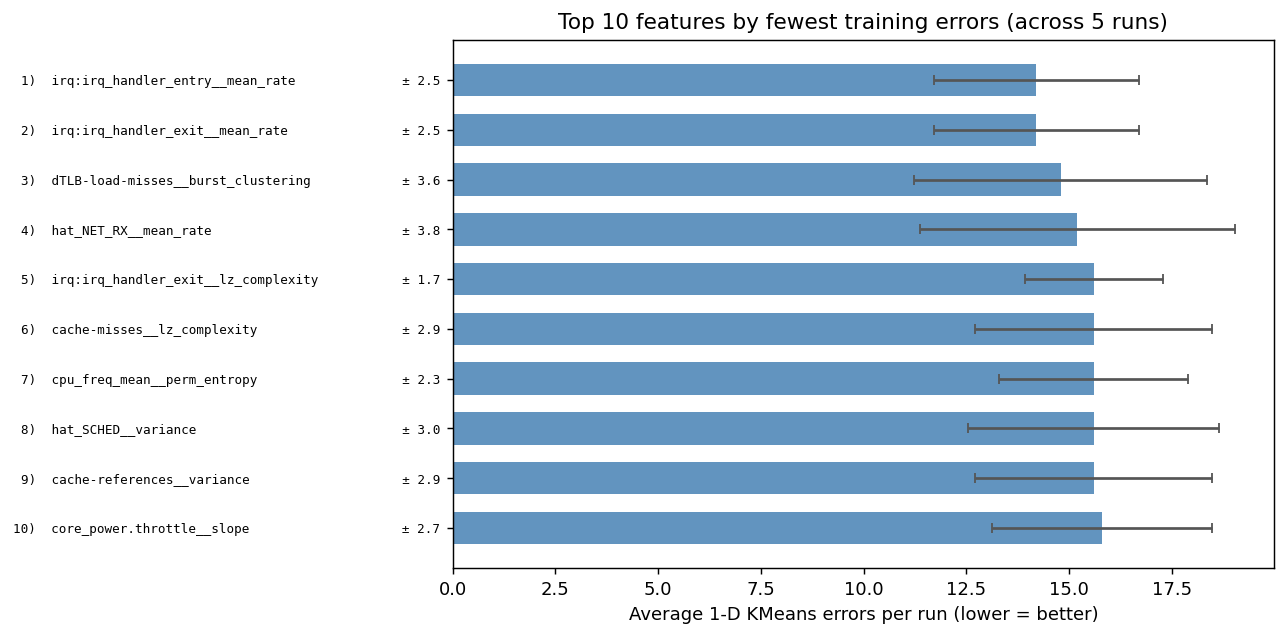

In [155]:
# ── Cross-run error aggregation: errorsA/B/D/E/F ────────────────────────────
err_frames = []
for run in RUNS:
    path = FEAT_DIR / f'errors{run}.csv'
    if path.exists():
        tmp = pd.read_csv(path)
        tmp['run'] = run
        err_frames.append(tmp)
        print(f'  Loaded errors{run}.csv: {len(tmp)} features')
    else:
        print(f'  ⚠ errors{run}.csv not found')

err_all = pd.concat(err_frames, ignore_index=True)

# Sum and average errors across runs
err_agg = err_all.groupby('feature').agg(
    total_errors = ('n_errors', 'sum'),
    avg_errors   = ('n_errors', 'mean'),
    std_errors   = ('n_errors', 'std'),
    n_runs       = ('run', 'count'),
).reset_index().sort_values('avg_errors').reset_index(drop=True)

err_agg.to_csv(RESULTS_DIR / 'errors_cross_run.csv', index=False)
print(f'\nAggregated {len(err_agg)} features across {len(err_frames)} runs')
print(f'Saved → {RESULTS_DIR}/errors_cross_run.csv')

# ── Plot top 10 features by fewest average errors ────────────────────────────
TOP_ERR = 10
top_err = err_agg.head(TOP_ERR).copy()

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(TOP_ERR)

ax.barh(y_pos, top_err['avg_errors'], xerr=top_err['std_errors'].fillna(0),
        color='steelblue', alpha=0.85, capsize=3, ecolor='#555', height=0.65)

# Y-axis labels: "rank) feature   (± std)"
y_labels = [
    f"{i+1})  {row['feature'].ljust(45)} ± {row['std_errors']:.1f}"
    if pd.notna(row['std_errors']) else
    f"{i+1})  {row['feature'].ljust(45)}"
    for i, (_, row) in enumerate(top_err.iterrows())
]
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=7, family='monospace')
ax.invert_yaxis()
ax.set_xlabel('Average 1-D KMeans errors per run (lower = better)')
ax.set_title(f'Top {TOP_ERR} features by fewest training errors (across {len(err_frames)} runs)')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'errors_cross_run.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 — Interpretation of results

### The main finding: no feature survives all five robustness gates

Across **5 independent runs** (A, B, D, E, F) with **300 unique features** (291 present in all 5),
**zero features** pass every filter simultaneously (rank ≤ 50, present in ≥ 3/5 runs,
sign ≥ 60 %, p < .05 in ≥ 40 % of runs, ARI > 0.05).
The bottleneck is **clustering power**: only **18 features** reach p < .05 in ≥ 40 %
of their runs, and only **4** have mean ARI above 0.05. Almost the entire ARI scatter plot
is red (significant in < 3/5 runs).

### What the plots show

| Plot | Key observation |
|---|---|
| **Rank consistency** (bar chart) | Error bars remain wide — a feature ranked top-10 in one run can fall to 200+ in another. The top-ranked feature (`msr/cpu_thermal_margin/__spectral_entropy`, rank 72 ± 35) is the most stable but still has low ARI (0.02) and only 20 % significance. New IRQ features (`irq:irq_handler_exit__mean_rate`, `irq:irq_handler_entry__mean_rate`) appear tied at rank 77 with ARI 0.07 and 40 % significance — the best-looking candidates. |
| **ARI scatter** | The cloud still hugs the origin; no feature sits in the desirable bottom-right corner (high ARI, low std). All dots are red — none reach p < .05 in ≥ 3/5 runs. Features with ARI > 0.05 have std ≈ 0.06–0.11, so clustering power is comparable to noise. |
| **Rank trajectory** (bump chart) | Lines cross wildly across runs — no feature holds a consistent position. The new `irq:entry` / `irq:exit` pairs track each other perfectly (identical values), confirming they measure the same underlying signal. |
| **Significance heatmap** | Direction arrows are mostly consistent within a feature (many show ↓E or ↑E across runs), but cells are pale — p-values rarely drop below 0.05. ★ markers are sparse and concentrated in runs B, D, and F. |

### The closest candidates (top features by composite rank)

No feature passed the strict gates, but the following show the best *relative* stability across 5 runs:

| Feature | Rank (mean ± std) | ARI | Sig % | Sign | Runs |
|---|---|---|---|---|---|
| `cache-misses__lz_complexity` | 74 ± 76 | 0.05 | 40 % | ↑E | 5/5 |
| `irq:irq_handler_exit__mean_rate` | 77 ± 68 | 0.07 | 40 % | ↓E | 5/5 |
| `irq:softirq_exit__p90_p10` | 78 ± 76 | 0.04 | 20 % | ↑E | 5/5 |
| `dTLB-load-misses__burst_clustering` | 95 ± 85 | 0.07 | 40 % | ↓E | 5/5 |
| `page-faults__mean_rate` | 96 ± 103 | 0.04 | 40 % | ↓E | 5/5 |

The IRQ handler entry/exit pair are tied because they fire on the same events; they represent
the single strongest univariate signal (ARI 0.07, sig 40 %, sign 80 %).
Rank standard deviations are still nearly as large as the means, and ARI values remain very
low (≤ 0.07). These are *hints*, not reliable single-feature classifiers.

### Why this happens

1. **Small sample size per run** (n ≈ 20 + 20 = 40). Mann-Whitney U at n = 20 vs 20 has
   low power for small effect sizes — many true differences will not reach p < 0.05.
2. **Session-level noise** dominates. Thermal state, LLC residency, background daemons,
   and scheduling jitter shift the distribution of counter values between runs, washing
   out subtle emotional–neutral differences.
3. **No single HPC feature is strongly discriminative** at this sample size. The raw effect
   sizes (r ≈ 0.25–0.47 in any one run) shrink and become inconsistent across sessions.
4. **Adding 62 new features** (300 vs 238 before) did not surface a robust candidate —
   the additional metrics follow the same pattern of inconsistent significance.

### Implications for the project

- **More trials per run** would increase statistical power and likely promote a handful of
  these candidates past the significance gate.
- **Feature combinations** (e.g., PCA, multi-feature KMeans) may capture signal that no
  single counter can, as explored in `clemson_clustering_analysis_clean.ipynb`.
- The **direction consistency** results are encouraging: 293/300 features agree on ↑E or ↓E
  in ≥ 60 % of runs — the signal *direction* is broadly reproducible, even when p-values
  fail to reach significance in individual 20-trial sessions.
- The **IRQ handler rate** features are the most promising single-feature candidates to
  monitor in future experiments with larger sample sizes.